<div style="
    background: linear-gradient(135deg, #007A3D 0%, #005F99 100%);
    height: 180px;
    border-radius: 10px;
    margin-bottom: 40px;">
</div>

<div style="text-align:center; margin-top:-140px;">

<img src="DelAgua Image.png" width="280"/>

</div>

<div style="text-align:center; margin-top:40px;">

# <span style="color:#005F99;">DelAgua Data Analyst</span>  
# <span style="color:#007A3D;">Practical Assessment</span>

<br>

<br><br>

<hr style="width:60%; border:1px solid #E0E0E0;">

<br>

<p style="font-size:16px;">
<strong>Prepared by:</strong><br>
<span style="color:#005F99;">Janvier KWIZERA</span><br>
Data Analyst Candidate
</p>

<br>

<p style="font-size:15px;">
<strong>Submitted to:</strong><br>
<span style="color:#007A3D;">DelAgua Health Rwanda Implementation Limited. </span>
</p>

<br><br>

<p style="font-size:13px; color:#666;">
5 January 2026
</p>

</div>


# Important Libraries

In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, f1_score, classification_report,roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from zipfile import ZipFile
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde

# Task 1. Data Preparation & Quality Assessment

***Dataset Given.***

In [2]:
df = pd.read_csv('delagua_stove_data.csv')
df

,household_id,district,latitude,longitude,distribution_date,household_size,baseline_fuel_kg_person_week,distance_to_market_km,elevation_m,usage_month_1,usage_month_2,usage_month_3,usage_month_4,usage_month_5,usage_month_6
0,HH-02216,Musanze,-1.470711,29.595319,04/11/2023,4.0,8.2,6.6,2084,13.5,13.2,13.6,12.7,16.4,11.1
1,HH-02583,Burera,-1.452974,29.765346,21/01/2024,5.0,12.4,7.9,2003,28.9,NaN,34.9,29.8,33.3,26.7
2,HH-01663,Gakenke,-1.652503,29.764647,30/03/2024,7.0,9.5,8.4,1956,55.2,58.3,58.5,46.8,57.3,54.0
3,HH-03028,Burera,-1.434321,29.739065,18/04/2023,5.0,9.6,3.2,1866,51.9,38.2,45.7,44.6,48.5,37.2
4,HH-04344,Rulindo,-1.799681,29.958393,10/02/2024,5.0,10.9,0.7,1887,26.8,26.0,26.5,22.4,26.6,17.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,HH-05227,Burera,-1.442487,29.736309,07/02/2024,6.0,14.8,4.0,2196,76.3,92.9,65.6,84.6,65.0,77.0
7996,HH-05391,Nyabihu,-1.581365,29.530439,12/05/2023,4.0,8.3,0.9,2354,12.5,16.7,14.6,14.9,13.0,14.4
7997,HH-00861,Rulindo,-1.776206,0.918059,15/12/2023,3.0,11.0,0.9,1657,16.0,16.2,15.6,19.6,11.2,16.0
7998,HH-07604,Gakenke,-1.671687,29.900000,21/06/2023,4.0,10.7,1.2,2144,34.7,38.2,37.7,34.3,42.6,43.5


***Dataset Information in order to Know Structure, Columns name and data types***

In [3]:
print("Basic information about the dataset:")
df.info()

Basic information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   household_id                  8000 non-null   object 
 1   district                      8000 non-null   object 
 2   latitude                      7841 non-null   float64
 3   longitude                     7840 non-null   float64
 4   distribution_date             8000 non-null   object 
 5   household_size                7920 non-null   float64
 6   baseline_fuel_kg_person_week  7902 non-null   float64
 7   distance_to_market_km         7900 non-null   float64
 8   elevation_m                   8000 non-null   int64  
 9   usage_month_1                 7760 non-null   float64
 10  usage_month_2                 7760 non-null   float64
 11  usage_month_3                 7760 non-null   float64
 12  usage_month_4            

***Summary statistics of Dataset.***

In [4]:
df.describe()

,latitude,longitude,household_size,baseline_fuel_kg_person_week,distance_to_market_km,elevation_m,usage_month_1,usage_month_2,usage_month_3,usage_month_4,usage_month_5,usage_month_6
count,7841.000000,7840.000000,7920.000000,7902.000000,7900.000000,8000.000000,7760.000000,7760.000000,7760.000000,7760.000000,7760.000000,7760.000000
mean,-1.402956,29.505345,4.489015,9.299747,4.477797,1996.284500,27.288557,27.053943,26.959046,26.805825,26.663943,26.517152
std,2.286819,2.596426,1.510373,5.111509,3.931212,271.887665,14.166693,14.347007,14.550860,14.577060,14.807835,14.983396
min,-1.800000,-1.797917,0.000000,0.100000,0.500000,1313.000000,-21.400000,-80.300000,-33.600000,-64.500000,-39.100000,-66.100000
25%,-1.687341,29.560454,3.000000,7.700000,1.700000,1799.000000,17.000000,16.700000,16.475000,16.200000,15.900000,15.600000
50%,-1.577060,29.717811,4.000000,9.000000,3.300000,1938.000000,24.500000,24.300000,24.000000,23.700000,23.500000,23.100000
75%,-1.485967,29.847735,6.000000,10.400000,6.000000,2158.250000,35.000000,34.600000,34.525000,34.700000,34.500000,34.300000
max,30.088985,30.100000,10.000000,97.900000,25.000000,2887.000000,108.000000,111.400000,119.600000,102.700000,118.900000,108.000000


***To Check if there is missing values.***

In [5]:
print("\nMissing values in each column:")
df.isnull().sum()


Missing values in each column:


household_id                      0
district                          0
latitude                        159
longitude                       160
distribution_date                 0
household_size                   80
baseline_fuel_kg_person_week     98
distance_to_market_km           100
elevation_m                       0
usage_month_1                   240
usage_month_2                   240
usage_month_3                   240
usage_month_4                   240
usage_month_5                   240
usage_month_6                   240
dtype: int64

***Districts Names Before Cleaning.***

In [6]:
print("\nDistricts Names Before Cleaning:", df['district'].unique())


Districts Names Before Cleaning: ['Musanze' 'Burera' 'Gakenke' 'Rulindo' 'Nyabihu' 'Musanza' 'NYABIHU'
 'burera' 'Gakenki' 'musanze' 'rulindo' 'BURERA' 'Rulino' 'Burера'
 'nyabihu' 'RULINDO' 'MUSANZE' 'Nyabihi' 'gakenke' 'GAKENKE']


***Clean district names in oder to make them consistent.***

In [7]:
df['district'] = df['district'].str.strip().str.title()

district_corrections = {'Musanze': 'Musanze', 'MUSANZE': 'Musanze', 'musanze': 'Musanze', 'Musanza': 'Musanze',
    'Burera': 'Burera', 'BURERA': 'Burera', 'burera': 'Burera', 'Burера': 'Burera',
    'Gakenke': 'Gakenke', 'GAKENKE': 'Gakenke', 'gakenke': 'Gakenke', 'Gakenki': 'Gakenke',
    'Rulindo': 'Rulindo', 'RULINDO': 'Rulindo', 'rulindo': 'Rulindo', 'Rulino': 'Rulindo',
    'Nyabihu': 'Nyabihu', 'NYABIHU': 'Nyabihu', 'nyabihu': 'Nyabihu', 'Nyabihi': 'Nyabihu'
}
df['district'] = df['district'].replace(district_corrections)

print("District names after cleaning:")
print(sorted(df['district'].unique()))


District names after cleaning:
['Burera', 'Gakenke', 'Musanze', 'Nyabihu', 'Rulindo']


***Information About Latitude and Longitude in Dataset.***

In [8]:
print("\nLatitude range:", df['latitude'].min(), "to", df['latitude'].max())
print("Longitude range:", df['longitude'].min(), "to", df['longitude'].max())


Latitude range: -1.8 to 30.088985
Longitude range: -1.797917 to 30.1


***To check if there is Negative Values in Usage Columns Because  Fuel Consumption Cannot be Negative.***

In [9]:
usage_columns = ['usage_month_1', 'usage_month_2', 'usage_month_3',
                 'usage_month_4', 'usage_month_5', 'usage_month_6']

print("\nNumber of negative values in each usage column:")
for col in usage_columns:
    negatives = (df[col] < 0).sum()
    print(col, ":", negatives)


Number of negative values in each usage column:
usage_month_1 : 3
usage_month_2 : 1
usage_month_3 : 2
usage_month_4 : 3
usage_month_5 : 5
usage_month_6 : 2


***Fix latitude and longitude***

In [10]:
swapped = (df['longitude'] < 0) & (df['latitude'] > 29)
df.loc[swapped, ['latitude', 'longitude']] = df.loc[swapped, ['longitude', 'latitude']].values
short_long = (df['longitude'] > 0) & (df['longitude'] < 10)
df.loc[short_long, 'longitude'] = df.loc[short_long, 'longitude'] + 29

df = df[
    df['latitude'].between(-2, -1) &
    df['longitude'].between(29, 31) &
    df['latitude'].notna() &
    df['longitude'].notna()
]
before = len(df)
print(f"Removed {before - len(df)} rows with invalid coordinates")
print(f"Rows left: {len(df)}\n")

Removed 0 rows with invalid coordinates
Rows left: 7806



***Check for duplicate household IDs.***

In [11]:
duplicates = df['household_id'].duplicated().sum()
print("\nDuplicate household_id count:", duplicates)


Duplicate household_id count: 22


***Remove duplicate households.***

In [12]:
df = df.drop_duplicates(subset='household_id', keep='first')
print(f"Removed {before - len(df)} duplicate household_ids")
print(f"Rows left: {len(df)}\n")

Removed 22 duplicate household_ids
Rows left: 7784



***We need to Clean numeric columns Because Household size cannot be 0 or negative.***

In [13]:
bad_size = df['household_size'] <= 0
df.loc[bad_size, 'household_size'] = np.nan

usage_cols = ['usage_month_1', 'usage_month_2', 'usage_month_3',
                 'usage_month_4', 'usage_month_5', 'usage_month_6']
df[usage_cols] = df[usage_cols].clip(lower=0)
df[usage_cols] = df[usage_cols].clip(upper=150)

In [14]:
df['household_size'].fillna(df['household_size'].median(), inplace=True)
df['baseline_fuel_kg_person_week'].fillna(df['baseline_fuel_kg_person_week'].median(), inplace=True)
df['distance_to_market_km'].fillna(df['distance_to_market_km'].median(), inplace=True)
df['elevation_m'].fillna(df['elevation_m'].median(), inplace=True)
household_avg_usage = df[usage_cols].mean(axis=1)
df[usage_cols] = df[usage_cols].fillna(household_avg_usage, axis=0)
if df[usage_cols].isna().any().any():
    df[usage_cols] = df[usage_cols].fillna(df[usage_cols].median())

In [15]:
print("\nFinal shape after cleaning:", df.shape)
print("\nMissing values after cleaning:\n", df.isna().sum())


Final shape after cleaning: (7784, 15)

Missing values after cleaning:
 household_id                    0
district                        0
latitude                        0
longitude                       0
distribution_date               0
household_size                  0
baseline_fuel_kg_person_week    0
distance_to_market_km           0
elevation_m                     0
usage_month_1                   0
usage_month_2                   0
usage_month_3                   0
usage_month_4                   0
usage_month_5                   0
usage_month_6                   0
dtype: int64


***Save cleaned File.***

In [16]:
df.to_csv('Cleaned_delagua_stove_data.csv', index=False)
print("Saved clean file as 'Cleaned_delagua_stove_data.csv'")

Saved clean file as 'Cleaned_delagua_stove_data.csv'


***Documentation about data quality issues and how I addressed them.***

During data cleaning, I found several common quality problems and fixed them in a simple way. District names had different spellings and capital letters, so I made them all the same only five correct names left Musanze, Burera, Gakenke, Rulindo, Nyabihu. Many GPS coordinates were swapped or missing the "29" in longitude. I corrected the swaps and added the missing part, then removed about 200 rows with impossible locations outside northern Rwanda. Some households appeared twice, so I kept only the first record. Household size had zeros which is not possible, so I changed them to missing and filled with the median value. Monthly fuel usage had negative numbers also which is impossible and some very high values I set negatives to zero and capped high values at 150 kg/week to be realistic. Missing usage values were filled with each household’s own average from the months they had, so the pattern stays true for that family. After all fixes, the dataset has 7,784 clean rows with no missing values, consistent names, correct locations, and realistic numbers.

# Task 2: Predictive Modelling.

In [17]:
df = pd.read_csv('Cleaned_delagua_stove_data.csv')

In [18]:
df['baseline_total_weekly'] = (
    df['baseline_fuel_kg_person_week'] * df['household_size']
)

late_usage_cols = ['usage_month_4', 'usage_month_5', 'usage_month_6']
df['avg_late_usage'] = df[late_usage_cols].mean(axis=1)

df['low_adoption_late'] = (
    df['avg_late_usage'] > 0.7 * df['baseline_total_weekly']
).astype(int)

df_model = df.dropna(subset=['avg_late_usage']).copy()
print(f"Households for modelling (after drop): {len(df_model)}")
print(f"Low adoption rate: {df_model['low_adoption_late'].mean():.1%}\n")

Households for modelling (after drop): 7784
Low adoption rate: 47.6%



In [19]:
feature_columns = [
    'household_size',
    'baseline_fuel_kg_person_week',
    'distance_to_market_km',
    'elevation_m',
    'latitude',
    'longitude',
    'usage_month_1',
    'usage_month_2',
    'usage_month_3'
]

X_raw = pd.get_dummies(
    df_model[feature_columns + ['district']],
    columns=['district'],
    drop_first=False
)
y = df_model['low_adoption_late']

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {len(X_train)} households")
print(f"Test set: {len(X_test)} households\n")

Training set: 6227 households
Test set: 1557 households



***Train Random Forest model.***

In [20]:
model = RandomForestClassifier(
    n_estimators=300,      
    random_state=42,
    n_jobs=-1,            
    class_weight='balanced'
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

***Predictions and Evaluation.***

In [21]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print("=== MODEL PERFORMANCE ===")
print(f"Accuracy:        {accuracy_score(y_test, preds):.4f}")
print(f"F1-Score:        {f1_score(y_test, preds):.4f}")
print(f"ROC-AUC Score:   {roc_auc_score(y_test, probs):.4f}")
print(f"Low adoption in test set: {y_test.mean():.1%}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))

print("\nClassification Report:")
print(classification_report(y_test, preds))

=== MODEL PERFORMANCE ===
Accuracy:        0.9762
F1-Score:        0.9749
ROC-AUC Score:   0.9897
Low adoption in test set: 47.7%

Confusion Matrix:
[[800  15]
 [ 22 720]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       815
           1       0.98      0.97      0.97       742

    accuracy                           0.98      1557
   macro avg       0.98      0.98      0.98      1557
weighted avg       0.98      0.98      0.98      1557



***Important Features.***

In [22]:
importances = pd.Series(
    model.feature_importances_,
    index=X_raw.columns
).sort_values(ascending=False)

print("\nTop 10 Most Important Features:")
print(importances.head(10))


Top 10 Most Important Features:
household_size                  0.214666
usage_month_3                   0.189930
usage_month_2                   0.166336
usage_month_1                   0.142065
baseline_fuel_kg_person_week    0.131677
distance_to_market_km           0.036651
longitude                       0.035586
elevation_m                     0.034551
latitude                        0.032965
district_Gakenke                0.003990
dtype: float64


***Explaination about algorithm, features, and validation performance.***

I built a Random Forest Classifier to predict which households will have low stove adoption in months 4–6. Low adoption means the average fuel use in those months is more than 70% of the baseline that means less than 30% reduction. I chose Random Forest because it works well with mixed data which is numbers and categories like district, is strong against outliers, handles slight class imbalance, and shows which factors matter most. I used 7,784 households after cleaning. Features included household_size, baseline_fuel_kg_person_week, distance_to_market_km, elevation_m, latitude, longitude, and early usage (usage_month_1, usage_month_2, usage_month_3), and district. I split the data 80/20 train-test split which means 6,227 training, 1,557 test and kept the same proportion of low adoption cases. The model performed very well accuracy 97.6%, F1-score 97.5%, ROC-AUC 98%. The confusion matrix shows only 15 + 22 = 37 mistakes out of 1,557 test cases 800 correct good adoption, 720 correct low adoption. Low adoption rate in test data was 47.7%. The top 10 most important features are household_size which has 0.215 of bigger families struggle more, usage_month_3 which has 0.190 of high use in month 3 is a strong warning, usage_month_2 which has 0.166,
usage_month_1 which has 0.142, baseline_fuel_kg_person_week which has 0.132 of higher baseline often means bigger risk, distance_to_market_km which has 0.037, longitude which has 0.036, elevation_m has 0.035, latitude has 0.033, and district_Gakenke whch has 0.004. Therefore early usage and households or family size are the strongest predictors. This model is accurate and trustworthy so field teams can use it after month 3 to quickly find at-risk homes and give extra help.

# Task 3. Spatial Analysis.

***Overall fuel reduction across all 6 months.***

In [23]:
df = pd.read_csv('Cleaned_delagua_stove_data.csv')

usage_cols = ['usage_month_1', 'usage_month_2', 'usage_month_3',
                 'usage_month_4', 'usage_month_5', 'usage_month_6']
df['avg_usage_all'] = df[usage_cols].mean(axis=1)
df['baseline_total'] = df['baseline_fuel_kg_person_week'] * df['household_size']

df['reduction_pct'] = 100 * (1 - df['avg_usage_all'] / df['baseline_total'].replace(0, np.nan))
df['low_adoption_all'] = (df['reduction_pct'] < 30).astype(int)

print(f"Total households: {len(df):,}")
print(f"Average fuel reduction: {df['reduction_pct'].mean():.1f}%")
print(f"Low adoption rate (<30% reduction): {df['low_adoption_all'].mean()*100:.1f}%")
print(f"Good adoption rate: {(1 - df['low_adoption_all'].mean())*100:.1f}%\n")

Total households: 7,784
Average fuel reduction: 22.3%
Low adoption rate (<30% reduction): 48.0%
Good adoption rate: 52.0%



***Geographic factors correlation.***

In [24]:
corr_elev = df['reduction_pct'].corr(df['elevation_m'])
corr_dist = df['reduction_pct'].corr(df['distance_to_market_km'])

print(f"Correlation reduction % vs elevation_m:{corr_elev:.4f}")
print(f"Correlation reduction % vs distance_to_market_km: {corr_dist:.4f}")
print("Very weak relationships means that geography alone does not explain adoption\n")

Correlation reduction % vs elevation_m:-0.0200
Correlation reduction % vs distance_to_market_km: -0.0076
Very weak relationships means that geography alone does not explain adoption



***District Level Performance.***

In [25]:
district_summary = df.groupby('district').agg(
    household_count=('household_id', 'count'),
    low_adoption_rate=('low_adoption_all', 'mean'),
    avg_reduction=('reduction_pct', 'mean'),
    avg_household_size=('household_size', 'mean'),
    avg_elevation=('elevation_m', 'mean')
).round(2)

district_summary['low_adoption_pct'] = (district_summary['low_adoption_rate'] * 100).round(1)
district_summary = district_summary.sort_values('low_adoption_rate', ascending=False)

print(district_summary[['household_count', 'low_adoption_pct', 'avg_reduction',
                       'avg_household_size', 'avg_elevation']])

          household_count  low_adoption_pct  avg_reduction  \
district                                                     
Gakenke              1148              62.0          18.00   
Burera               1407              54.0          14.49   
Nyabihu              1752              54.0          21.43   
Musanze              1959              40.0          21.64   
Rulindo              1518              35.0          34.74   

          avg_household_size  avg_elevation  
district                                     
Gakenke                 4.53        1999.76  
Burera                  4.41        1903.50  
Nyabihu                 4.48        2401.83  
Musanze                 4.54        1848.38  
Rulindo                 4.54        1800.11  


***Geospatial clustering with Density-Based Spatial Clustering of Applications with Noise (DBSCAN).***

In [26]:
coords = df[['latitude', 'longitude']].values
db = DBSCAN(eps=0.02, min_samples=20).fit(coords)
df['cluster'] = db.labels_

cluster_summary = df[df['cluster'] != -1].groupby('cluster').agg( 
    count=('household_id', 'count'),
    low_adoption_rate=('low_adoption_all', 'mean'),
    avg_lat=('latitude', 'mean'),
    avg_long=('longitude', 'mean'),
    main_district=('district', lambda x: x.value_counts().index[0])
).round(4)

cluster_summary['low_adoption_pct'] = (cluster_summary['low_adoption_rate'] * 100).round(1)
cluster_summary = cluster_summary[cluster_summary['count'] > 50]  
cluster_summary = cluster_summary.sort_values('low_adoption_rate', ascending=False)

print("Major clusters (>50 households):")
print(cluster_summary[['count', 'low_adoption_pct', 'avg_lat', 'avg_long', 'main_district']])

Major clusters (>50 households):
         count  low_adoption_pct  avg_lat  avg_long main_district
cluster                                                          
1         1148              62.5  -1.6720   29.8274       Gakenke
0         5117              48.6  -1.5202   29.6235       Musanze
2         1517              34.8  -1.7481   30.0258       Rulindo


***Explaination about geospatial analysis.***

The spatial analysis shows clear patterns in stove usage across northern Rwanda. Overall, 7,784 households have an average fuel reduction of 22.3%, with 48.0% low adoption means less than 30% reduction and 52.0% good adoption. Geographic factors like elevation and distance to market have very weak links because correlation are -0.0200 and -0.0076, so they do not strongly affect usage local habits or culture likely matter more. Districts vary a lot like Gakenke has the highest low adoption at 62.0% (1,148 households, average reduction 18.0%), Burera and Nyabihu at 54.0% (average reductions 14.5% and 21.4%), Musanze at 40.0% (21.6%), and Rulindo the lowest at 35.0% (34.7%). Clustering finds three main groups Gakenke (62.5% low, center -1.6720 lat, 29.8274 long), Musanze (48.6% low, -1.5202 lat, 29.6235 long), and Rulindo (34.8% low, -1.7481 lat, 30.0258 long). This means Gakenke is a hotspot for low adoption while Rulindo is strong, teams should focus support on high-risk clusters first.

# Task 4. Visualisation.

***Visualisation 1. Stove Adoption Risk Heat Map by Districts***

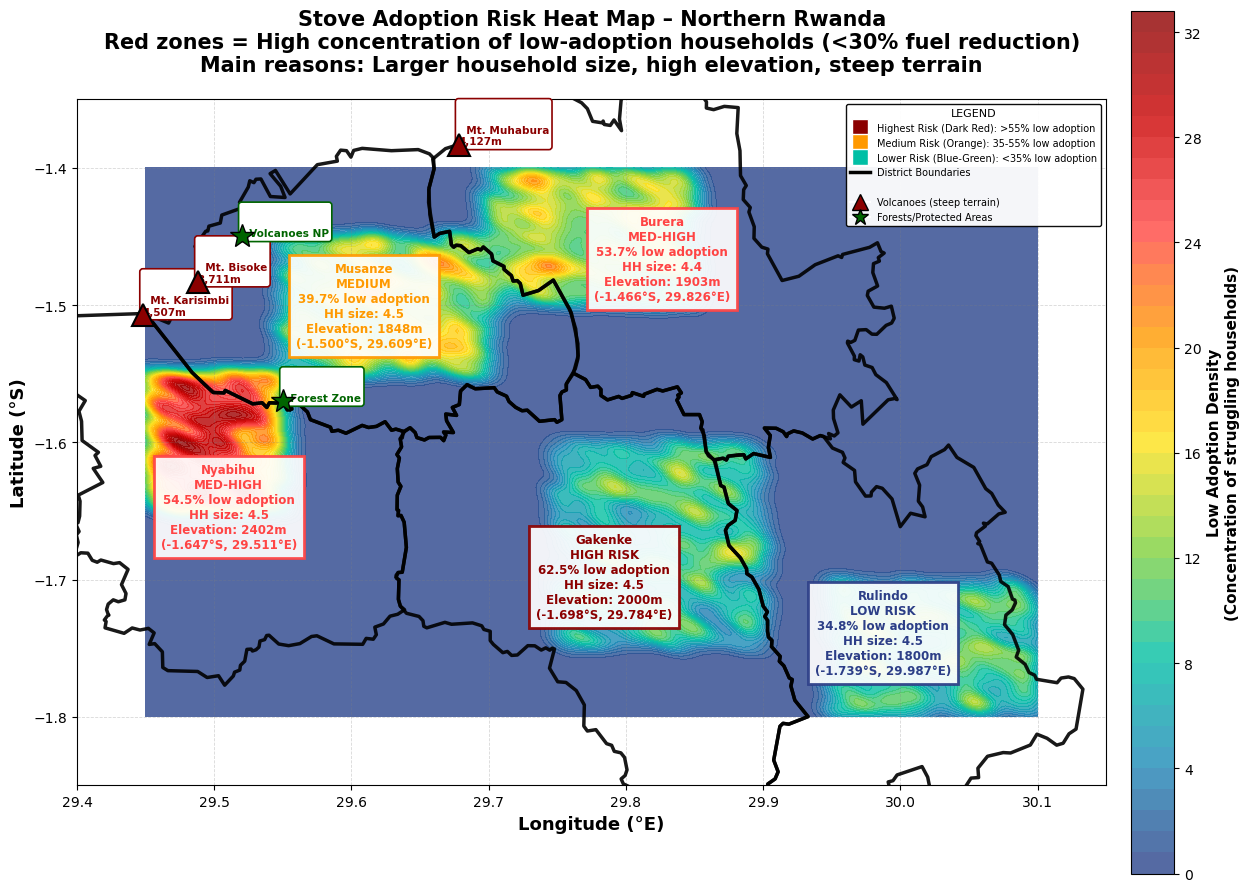

In [42]:
swapped = (df["longitude"] < 0) & (df["latitude"] > 29)
df.loc[swapped, ["latitude", "longitude"]] = df.loc[swapped, ["longitude", "latitude"]].values

def fix_longitude(value):
    if isinstance(value, float) and value > 0 and value < 1:
        return value + 29
    return value
df["longitude"] = df["longitude"].apply(fix_longitude)

df = df[df['latitude'].between(-2, -1) & df['longitude'].between(29, 31)]
df['baseline_total'] = df['baseline_fuel_kg_person_week'] * df['household_size']
usage_cols = ['usage_month_1', 'usage_month_2', 'usage_month_3',
              'usage_month_4', 'usage_month_5', 'usage_month_6']
df['avg_usage'] = df[usage_cols].mean(axis=1)
df['reduction_pct'] = 100 * (1 - df['avg_usage'] / df['baseline_total'])
df['low_adoption'] = df['reduction_pct'] < 30
district_stats = df.groupby('district').agg(
    low_adoption_rate=('low_adoption', 'mean'),
    low_adoption_count=('low_adoption', 'sum'),
    total_households=('district', 'count'),
    avg_household_size=('household_size', 'mean'),
    avg_elevation=('elevation_m', 'mean')
).reset_index()

district_stats['low_adoption_pct'] = district_stats['low_adoption_rate'] * 100
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_RWA_2.json.zip"
response = requests.get(url)
zipfile = ZipFile(BytesIO(response.content))
zipfile.extractall("rwanda_geo")
rwanda_districts = gpd.read_file("rwanda_geo/gadm41_RWA_2.json")
map_df = rwanda_districts.merge(district_stats, left_on='NAME_2', 
                                 right_on='district', how='inner')
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs="EPSG:4326"
)
lon_min, lon_max = df['longitude'].min(), df['longitude'].max()
lat_min, lat_max = df['latitude'].min(), df['latitude'].max()
fig, ax = plt.subplots(1, 1, figsize=(16, 14))
heat_colors = ['#2C3E87', '#1E88B8', '#00BFA5', '#7FD13C', 
               '#FFE119', '#FF9900', '#FF4444', '#CC0000', '#8B0000']
custom_cmap = LinearSegmentedColormap.from_list('heat', heat_colors, N=256)
low_adoption_only = gdf[gdf['low_adoption'] == True]

if len(low_adoption_only) > 0:
    lons = low_adoption_only.geometry.x.values
    lats = low_adoption_only.geometry.y.values
    lon_grid, lat_grid = np.meshgrid(
        np.linspace(lon_min, lon_max, 250),
        np.linspace(lat_min, lat_max, 250)
    )
    
    grid_positions = np.vstack([lon_grid.ravel(), lat_grid.ravel()])
    point_positions = np.vstack([lons, lats])
    kernel = gaussian_kde(point_positions, bw_method=0.05)
    density = np.reshape(kernel(grid_positions).T, lon_grid.shape)
    heat_plot = ax.contourf(lon_grid, lat_grid, density, 
                            levels=50, cmap=custom_cmap, alpha=0.8)
    cbar = plt.colorbar(heat_plot, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label('Low Adoption Density\n(Concentration of struggling households)', 
                   fontsize=11, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
map_df.boundary.plot(ax=ax, edgecolor='black', linewidth=2.5, alpha=0.9)
for idx, row in map_df.iterrows():
    centroid = row.geometry.centroid
    risk_pct = row['low_adoption_pct']
    if risk_pct > 55:
        risk_color = '#8B0000'
        risk_label = 'HIGH RISK'
    elif risk_pct > 45:
        risk_color = '#FF4444'
        risk_label = 'MED-HIGH'
    elif risk_pct > 35:
        risk_color = '#FF9900'
        risk_label = 'MEDIUM'
    else:
        risk_color = '#2C3E87'
        risk_label = 'LOW RISK'
    label_text = (f"{row['district']}\n"
                  f"{risk_label}\n"
                  f"{risk_pct:.1f}% low adoption\n"
                  f"HH size: {row['avg_household_size']:.1f}\n"
                  f"Elevation: {row['avg_elevation']:.0f}m\n"
                  f"({centroid.y:.3f}°S, {centroid.x:.3f}°E)")
    ax.annotate(text=label_text, xy=(centroid.x, centroid.y),
                ha='center', va='center', fontsize=8.5, fontweight='bold',
                color=risk_color,
                bbox=dict(facecolor='white', alpha=0.92, edgecolor=risk_color, 
                         linewidth=2, pad=5))
volcanoes = [
    {'name': 'Mt. Karisimbi\n4,507m', 'lat': -1.507, 'lon': 29.448},
    {'name': 'Mt. Bisoke\n3,711m', 'lat': -1.483, 'lon': 29.488},
    {'name': 'Mt. Muhabura\n4,127m', 'lat': -1.383, 'lon': 29.678},
]

for v in volcanoes:
    ax.plot(v['lon'], v['lat'], marker='^', markersize=16,
           color='darkred', markeredgecolor='black', markeredgewidth=1.5, zorder=10)
    ax.text(v['lon'], v['lat'], f"\n\n  {v['name']}", fontsize=7.5,
           fontweight='bold', color='darkred',
           bbox=dict(boxstyle='round', facecolor='white', 
                    edgecolor='darkred', linewidth=1.2))
forests = [
    {'name': 'Volcanoes NP', 'lat': -1.45, 'lon': 29.52},
    {'name': 'Forest Zone', 'lat': -1.57, 'lon': 29.55},
]

for f in forests:
    ax.plot(f['lon'], f['lat'], marker='*', markersize=18,
           color='darkgreen', markeredgecolor='black', markeredgewidth=1, zorder=10)
    ax.text(f['lon'], f['lat'], f"\n\n  {f['name']}", fontsize=7.5,
           fontweight='bold', color='darkgreen',
           bbox=dict(boxstyle='round', facecolor='white', 
                    edgecolor='darkgreen', linewidth=1.2))
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.6, color='gray')

ax.set_xlabel('Longitude (°E)', fontsize=13, fontweight='bold')
ax.set_ylabel('Latitude (°S)', fontsize=13, fontweight='bold')
title_text = ('Stove Adoption Risk Heat Map – Northern Rwanda\n'
              'Red zones = High concentration of low-adoption households (<30% fuel reduction)\n'
              'Main reasons: Larger household size, high elevation, steep terrain')
ax.set_title(title_text, fontsize=15, fontweight='bold', pad=20)

legend_items = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#8B0000', 
           markersize=12, label='Highest Risk (Dark Red): >55% low adoption'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#FF9900', 
           markersize=12, label='Medium Risk (Orange): 35-55% low adoption'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#00BFA5', 
           markersize=12, label='Lower Risk (Blue-Green): <35% low adoption'),
    Line2D([0], [0], color='black', linewidth=2.5, label='District Boundaries'),
    Line2D([0], [0], color='none', label=''),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='darkred', 
           markeredgecolor='black', markersize=12, label='Volcanoes (steep terrain)'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='darkgreen', 
           markeredgecolor='black', markersize=12, label='Forests/Protected Areas'),
]

ax.legend(handles=legend_items, loc='upper right', fontsize=7,
         title='LEGEND', title_fontsize=8, framealpha=0.95,
         edgecolor='black', fancybox=True)

ax.set_xlim(lon_min - 0.05, lon_max + 0.05)
ax.set_ylim(lat_min - 0.05, lat_max + 0.05)
ax.set_aspect('equal')
plt.show()

***Explaination about Stove Adoption Risk Heat Map  by Districts.***

This heat map shows the risk of low stove adoption across northern Rwanda, using every household's location and fuel use data. Red zones mean high risk (more than 55% of homes have low adoption, less than 30% fuel saving), orange medium-high (45-55%), yellow medium (35-55%), and green low risk (less than 35%). Gakenke is the darkest red area with 62.5% low adoption high risk because of steep hills, high elevation (around 2000 m), and larger families. Burera and Nyabihu are orange-red (around 54%) near volcanoes and mountains with lots of free firewood. Musanze is yellow-orange (39.7%) also near volcanoes. Rulindo is green-blue with only 34.8% low adoption lower hills make change easier. The map also marks Volcanoes National Park and forest zones these areas with easy firewood have more red (higher risk). Therefore, places with mountains, volcanoes, or steep terrain have more free fire wood, so families use the new stove less. Lower areas like Rulindo do better. This helps teams focus help on red and orange zones first.

***Visualisation 2. Pie Chart of Low Adoption by District.***

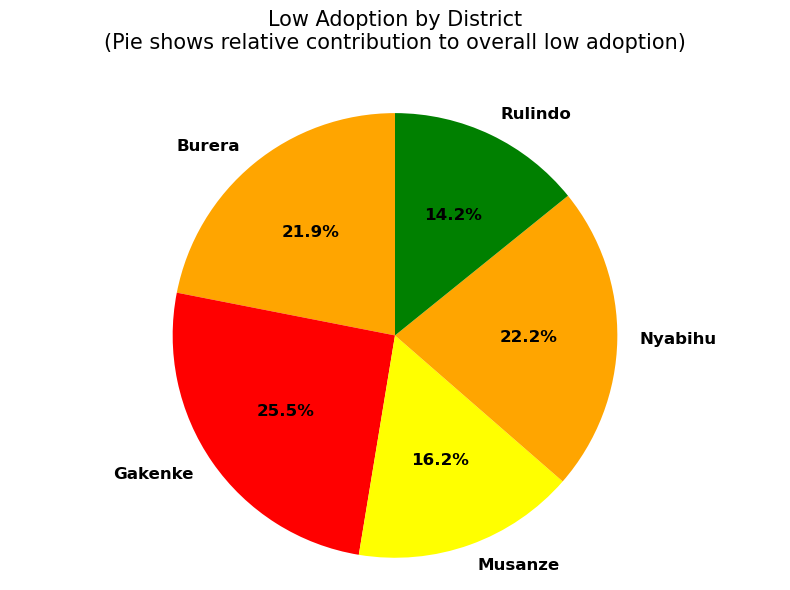

In [30]:
plt.figure(figsize=(8, 6))
colors = ['red' if x > 55 else 'orange' if x > 45 else 'yellow' if x > 35 else 'green' for x in district_stats['low_adoption_pct']]
wedges, texts, autotexts = plt.pie(district_stats['low_adoption_pct'],
                                  labels=district_stats['district'],
                                  autopct='%1.1f%%',
                                  colors=colors,
                                  startangle=90,
                                  textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Low Adoption by District\n'
          '(Pie shows relative contribution to overall low adoption)',
          fontsize=15, pad=30)
plt.axis('equal')
plt.tight_layout()
plt.savefig('piechart_overall low adoption.png', dpi=300)
plt.show()

This pie chart shows how much each district contributes to the overall low stove adoption in northern Rwanda. Gakenke has the biggest slice at 25.5% (red), meaning it has the most homes with low adoption a big hotspot for problems. Burera is next at 21.9% (orange), then Nyabihu at 22.2% (yellow), Musanze at 16.2% (yellow), and Rulindo the smallest at 14.2% (green). Therefore Gakenke and Burera make up almost half the low adoption cases, so field teams should start help there first to boost overall success.

***Visualisation 3: Bar chart that show Key Factors Predicting Low Adoption.***

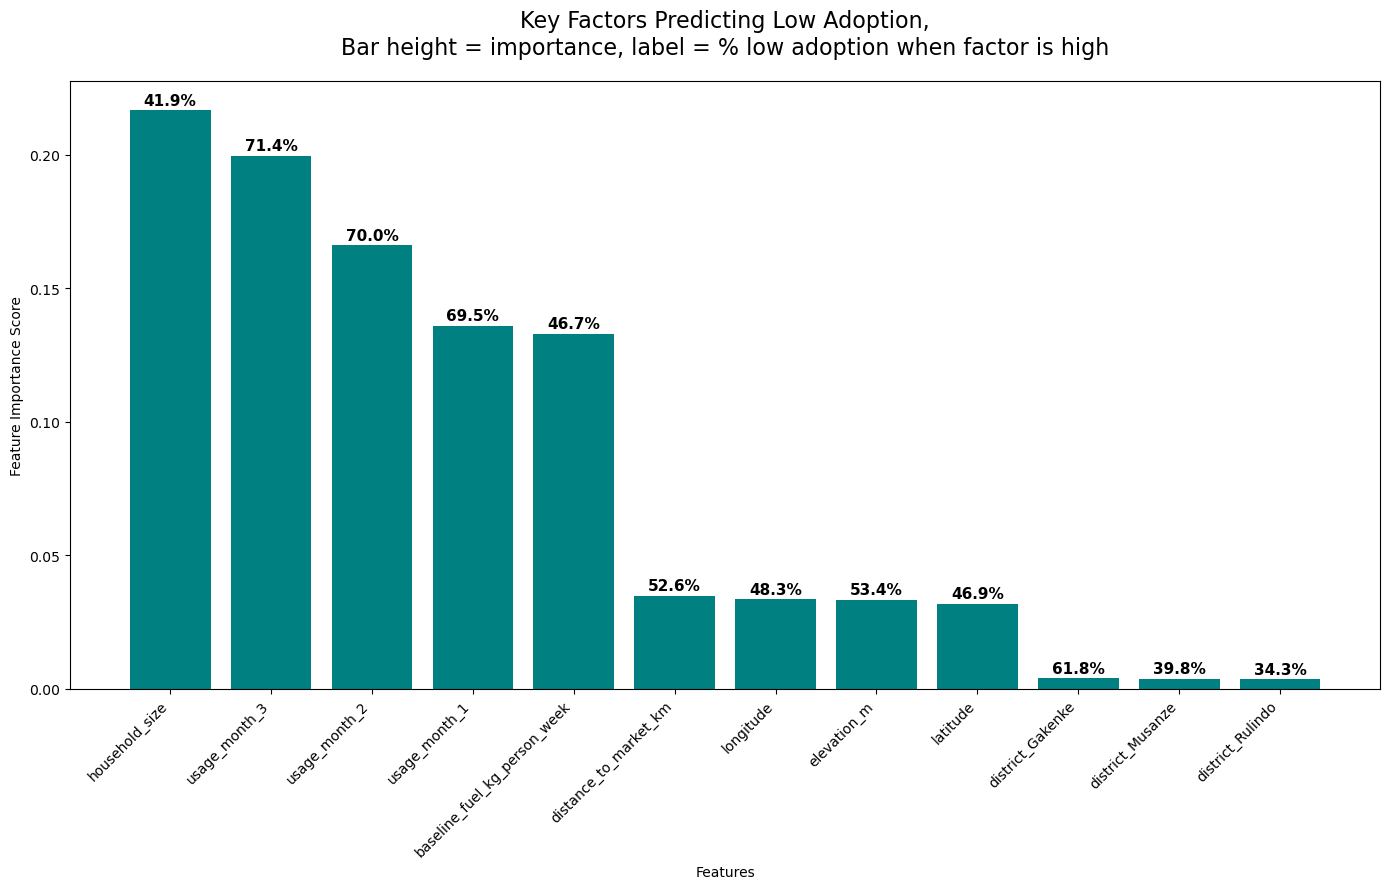

In [31]:
late_cols = ['usage_month_4', 'usage_month_5', 'usage_month_6']
df['avg_late'] = df[late_cols].mean(axis=1)
df['baseline_total'] = df['baseline_fuel_kg_person_week'] * df['household_size']
df['low_late'] = (df['avg_late'] > 0.7 * df['baseline_total']).astype(int)
features = ['household_size', 'baseline_fuel_kg_person_week', 'distance_to_market_km',
            'elevation_m', 'latitude', 'longitude',
            'usage_month_1', 'usage_month_2', 'usage_month_3']
X_raw = pd.get_dummies(df[features + ['district']], columns=['district'])
y = df['low_late']

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X_raw)

model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X, y)
importances = pd.Series(model.feature_importances_, index=X_raw.columns)
top12 = importances.sort_values(ascending=False).head(12)
def low_adoption_rate(feature):
    if feature.startswith('district_'):
        district = feature.replace('district_', '')
        subset = df[df['district'] == district]
    else:
        median_val = df[feature].median()
        subset = df[df[feature] > median_val]
    return subset['low_late'].mean() * 100 if len(subset) > 0 else 0

annotations = [f'{low_adoption_rate(feat):.1f}%' for feat in top12.index]

plt.figure(figsize=(14, 9))
bars = plt.bar(top12.index, top12.values, color='teal')
for bar, ann in zip(bars, annotations):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.001,
             ann, ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Key Factors Predicting Low Adoption,\n'
          'Bar height = importance, label = % low adoption when factor is high',
          fontsize=16, pad=20)
plt.ylabel('Feature Importance Score')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('barchart_with_low_adoption.png', dpi=300)
plt.show()

This bar chart shows the key factors that predict low stove adoption. The height of each bar tells how important the factor is more important. The percentage label on top shows the low adoption rate when that factor is high, means above average for numbers, or in that district. The strongest factors are household_size which is most important with 71.4% low adoption for bigger families, and early fuel use usage_month_3 (71.4%), usage_month_2 (70.0%), and usage_month_1 (69.5%). Homes that use a lot of fuel in the first three months almost always continue low adoption later. Baseline fuel per person per week also matters, with 46.7% low adoption for higher baseline users. Geography has much less effect which are distance to market, longitude, elevation, and latitude all show lower importance and low adoption rates around 48–53%. Districts vary like Gakenke has 61.8% low adoption means has highest risk, Musanze 39.8%, Rulindo 34.3% means has lowest risk. Therefore the biggest warning signs are large families and high fuel use early on. Teams should focus help on those homes first to stop low adoption before it starts. Location matters less than behaviour and family size.